# Adaptive RAG Pipeline [Step 3 - Full Classification-Retrieval-Generation]

> **MLCourse - Agentic AI - Adaptive RAG**

This notebook brings everything together into a single adaptive RAG
pipeline built with LangGraph.  Every incoming query flows through
four stages: classify, route, retrieve, and generate.  The graph
dynamically selects the best retrieval strategy based on query complexity
and produces a grounded answer.  We also visualize the full graph structure.

### What you will learn

1. How to wire classification, routing, retrieval, and generation into one LangGraph.
2. How conditional edges implement the adaptive branching logic.
3. How to visualize the complete pipeline with draw_mermaid_png().
4. How the pipeline handles every query type end to end.

In [1]:
import os
import re
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path

from dotenv import load_dotenv
load_dotenv()

False

In [2]:
# ## 1. Configuration

def find_track(start: Path, target: str = "03_agentic_ai") -> Path:
    """Climb parent folders until the track directory appears."""
    for candidate in [start, *start.parents]:
        probe = candidate / target
        if probe.is_dir():
            return probe
    raise FileNotFoundError(f"Could not find '{target}' above {start}")

TRACK = find_track(Path.cwd())
DATA = TRACK / "data"
DATA.mkdir(exist_ok=True)

print("[setup] TRACK:", TRACK)
print("[setup] DATA :", DATA)

[setup] TRACK: D:\projects\python\MLCourse\03_agentic_ai
[setup] DATA : D:\projects\python\MLCourse\03_agentic_ai\data


In [3]:
# ## 2. Ingest Alice and Build All Retrieval Backends
# We create three retrieval backends from the same document set: vector
# search (FAISS), keyword search (BM25), and a simulated web search stub.

from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

ALICE_PATH = DATA / "alice.txt"
raw_text = ALICE_PATH.read_text(encoding="utf-8-sig")[:20_000]

marks = list(re.finditer(r"^CHAPTER [IVX]+\.", raw_text, flags=re.MULTILINE))
splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

documents = []
for i, mark in enumerate(marks):
    seg_end = marks[i + 1].start() if i + 1 < len(marks) else len(raw_text)
    for piece in splitter.split_text(raw_text[mark.start():seg_end]):
        documents.append(Document(
            page_content=piece,
            metadata={"source": "alice", "chapter": str(i + 1)},
        ))

print(f"[ingest] chunks: {len(documents)}")

[ingest] chunks: 60


In [4]:
# ### 2a. Vector Retriever

from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

embeddings = HuggingFaceEmbeddings(model_name="sentence-transformers/all-MiniLM-L6-v2")
vectordb = FAISS.from_documents(documents, embeddings)
vector_retriever = vectordb.as_retriever(search_kwargs={"k": 4})
print("[retriever] FAISS vector retriever ready (k=4)")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

[retriever] FAISS vector retriever ready (k=4)


In [5]:
# ### 2b. Keyword Retriever

from langchain_community.retrievers import BM25Retriever

bm25_retriever = BM25Retriever.from_documents(documents, k=4)
print("[retriever] BM25 keyword retriever ready (k=4)")

[retriever] BM25 keyword retriever ready (k=4)


In [6]:
# ## 3. Initialize the LLM

from langchain_ollama import ChatOllama

llm = ChatOllama(model="llama3.1:8b", temperature=0)
print("[llm] ChatOllama ready:", llm.model)

[llm] ChatOllama ready: llama3.1:8b


In [7]:
# ## 4. Define the Graph State
# The state carries every piece of data the pipeline needs: the original
# query, the classification, the chosen strategy, retrieved context,
# the final answer, a quality verdict, and a full execution log.

from typing import TypedDict

class AdaptiveRAGState(TypedDict):
    query: str                       # original user question
    classification: str              # "factual", "analytical", "conversational", "out_of_scope"
    strategy: str                    # "vector", "bm25", "web", "direct"
    context: str                     # retrieved text joined together
    answer: str                      # final generated answer
    verdict: str                     # "pass" or "fail" from quality check
    route_log: list                  # full audit trail

print("[state] AdaptiveRAGState defined (8 fields)")

[state] AdaptiveRAGState defined (8 fields)


In [8]:
# ## 5. Build the Classification Node
# Reads the query and assigns one of four labels.

from langchain_core.prompts import ChatPromptTemplate

CLASSIFICATION_CRITERIA = """
You are a query classifier for an Alice in Wonderland knowledge base.
Classify the user query into EXACTLY one category:

- 'factual': asks about specific events, characters, dialogue, or details
  from Alice in Wonderland that can be found in a specific passage.
- 'analytical': requires reasoning about themes, causes, comparisons, or
  interpretations that need synthesis of multiple passages.
- 'conversational': greetings, opinions, meta questions, or small talk
  that does not need any document lookup.
- 'out_of_scope': completely unrelated to Alice in Wonderland.

Reply with ONLY the category label in lowercase.
"""

classifier_prompt = ChatPromptTemplate.from_messages([
    ("system", CLASSIFICATION_CRITERIA),
    ("user", "{query}")
])

VALID_CATEGORIES = ("factual", "analytical", "conversational", "out_of_scope")

def classify_query(state: AdaptiveRAGState) -> dict:
    """Node: classify the incoming query."""
    response = (classifier_prompt | llm).invoke({"query": state["query"]})
    raw = response.content.strip().lower()
    category = "out_of_scope"
    for cat in VALID_CATEGORIES:
        if cat in raw:
            category = cat
            break
    log = state.get("route_log", []) + [f"classify -> {category}"]
    print(f"  [classify] -> {category}")
    return {"classification": category, "route_log": log}

In [9]:
# ## 6. Build the Strategy Router
# Maps classification labels to retrieval strategies.

STRATEGY_MAP = {
    "factual":        "bm25",       # exact keyword match for specific details
    "analytical":     "vector",     # semantic search for conceptual questions
    "conversational": "direct",     # no retrieval needed
    "out_of_scope":   "web",        # attempt external search
}

def route_strategy(state: AdaptiveRAGState) -> str:
    """Determine the next node based on the classified query type."""
    classification = state.get("classification", "factual")
    strategy = STRATEGY_MAP.get(classification, "vector")
    next_node = f"retrieve_{strategy}" if strategy != "direct" else "direct_answer"
    log = state.get("route_log", []) + [f"route {classification} -> {strategy}"]
    print(f"  [route] {classification} -> {next_node}")
    return next_node

print("[router] Strategy map defined")

[router] Strategy map defined


In [10]:
# ## 7. Build the Retrieval Nodes
# One node per retrieval strategy.

def retrieve_vector(state: AdaptiveRAGState) -> dict:
    """Node: retrieve via FAISS vector similarity search."""
    docs = vector_retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    log = state.get("route_log", []) + [f"vector retrieved {len(docs)} chunks"]
    print(f"  [vector] {len(docs)} chunks, {len(context)} chars")
    return {"context": context, "route_log": log}

def retrieve_bm25(state: AdaptiveRAGState) -> dict:
    """Node: retrieve via BM25 keyword matching."""
    docs = bm25_retriever.invoke(state["query"])
    context = "\n\n".join(d.page_content for d in docs)
    log = state.get("route_log", []) + [f"bm25 retrieved {len(docs)} chunks"]
    print(f"  [bm25] {len(docs)} chunks, {len(context)} chars")
    return {"context": context, "route_log": log}

def retrieve_web(state: AdaptiveRAGState) -> dict:
    """Node: simulated web search (stub for offline execution)."""
    log = state.get("route_log", []) + ["web search (simulated)"]
    print(f"  [web] simulated search")
    return {"context": "[Web search unavailable in local mode]", "route_log": log}

def answer_direct(state: AdaptiveRAGState) -> dict:
    """Node: answer from LLM knowledge (no retrieval)."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Answer the question concisely in 1-3 sentences using your own "
         "knowledge.  Be helpful and friendly."),
        ("user", "{query}")
    ])
    response = (prompt | llm).invoke({"query": state["query"]})
    log = state.get("route_log", []) + ["direct answer (no retrieval)"]
    print(f"  [direct] answered from LLM knowledge")
    return {"answer": response.content, "context": "", "route_log": log}

In [11]:
# ## 8. Build the Answer Generator Node
# Shared by the three retrieval branches.  Produces a grounded answer.

def generate_answer(state: AdaptiveRAGState) -> dict:
    """Node: generate a grounded answer from retrieved context."""
    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "Answer the question using ONLY the provided context. "
         "If the context does not contain enough information, say so. "
         "Keep the answer to 2-4 sentences."),
        ("user", "Question: {query}\n\nContext:\n{context}")
    ])
    response = (prompt | llm).invoke({
        "query": state["query"],
        "context": state["context"]
    })
    log = state.get("route_log", []) + [f"generated answer ({len(response.content)} chars)"]
    print(f"  [generate] {len(response.content)} chars")
    return {"answer": response.content, "route_log": log}

In [12]:
# ## 9. Build the Quality Check Node
# A lightweight evaluator that verifies the answer is grounded in context.
# If it fails, we can flag the answer as unreliable.

def quality_check(state: AdaptiveRAGState) -> dict:
    """Node: verify the answer is faithful to the retrieved context."""
    if state["classification"] in ("conversational", "out_of_scope"):
        # Skip quality check for non-retrieval paths.
        log = state.get("route_log", []) + ["quality check skipped (no context)"]
        print(f"  [quality] skipped (non-retrieval path)")
        return {"verdict": "pass", "route_log": log}

    if not state.get("context"):
        log = state.get("route_log", []) + ["quality check skipped (empty context)"]
        return {"verdict": "pass", "route_log": log}

    prompt = ChatPromptTemplate.from_messages([
        ("system",
         "You are a quality checker for a RAG system.  Given the RETRIEVED CONTEXT "
         "and the GENERATED ANSWER, determine if the answer is faithful to the context.\n"
         "Reply with ONLY 'pass' or 'fail'.\n"
         "- 'pass' if the answer is grounded in the context.\n"
         "- 'fail' if the answer contains unsupported claims or contradictions."),
        ("user",
         "CONTEXT:\n{context}\n\nANSWER:\n{answer}")
    ])
    response = (prompt | llm).invoke({
        "context": state["context"],
        "answer": state["answer"]
    })
    verdict = response.content.strip().lower()
    if verdict not in ("pass", "fail"):
        verdict = "pass"  # safe default
    log = state.get("route_log", []) + [f"quality check: {verdict}"]
    print(f"  [quality] {verdict}")
    return {"verdict": verdict, "route_log": log}

In [13]:
# ## 10. Assemble the Full Adaptive RAG Graph
# The complete pipeline:
#
#   START -> classify -> route -> retrieve/direct -> generate -> quality -> END
#
# The classify node outputs a label, the route function dispatches to the
# appropriate retrieval node, the generator produces an answer, and the
# quality checker validates it.

from langgraph.graph import StateGraph, START, END

graph = StateGraph(AdaptiveRAGState)

# Add all nodes.
graph.add_node("classify", classify_query)
graph.add_node("retrieve_vector", retrieve_vector)
graph.add_node("retrieve_bm25", retrieve_bm25)
graph.add_node("retrieve_web", retrieve_web)
graph.add_node("direct_answer", answer_direct)
graph.add_node("generate", generate_answer)
graph.add_node("quality_check", quality_check)

# Entry edge.
graph.add_edge(START, "classify")

# Classification -> strategy routing.
graph.add_conditional_edges(
    "classify",
    route_strategy,
    {
        "retrieve_vector": "retrieve_vector",
        "retrieve_bm25": "retrieve_bm25",
        "retrieve_web": "retrieve_web",
        "direct_answer": "direct_answer",
    }
)

# Retrieval branches -> generator.
graph.add_edge("retrieve_vector", "generate")
graph.add_edge("retrieve_bm25", "generate")
graph.add_edge("retrieve_web", "generate")

# Generator -> quality check.
graph.add_edge("generate", "quality_check")

# Direct answer -> quality check (it also passes through for consistency).
graph.add_edge("direct_answer", "quality_check")

# Quality check -> END.
graph.add_edge("quality_check", END)

app = graph.compile()
print("[graph] adaptive RAG pipeline compiled")

[graph] adaptive RAG pipeline compiled


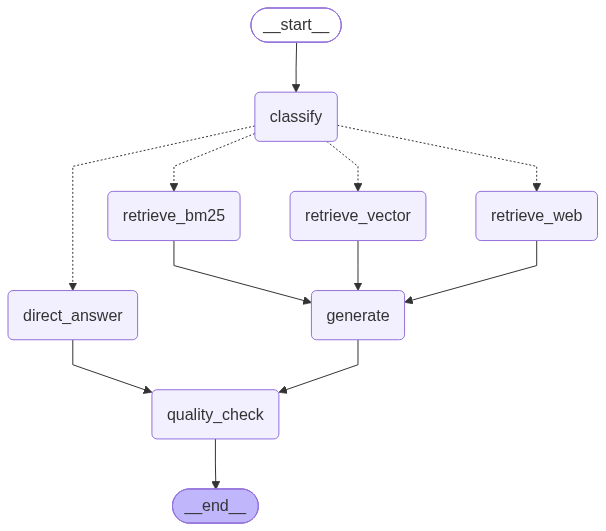

In [14]:
# ## 11. Visualize the Graph

from IPython.display import Image, display

try:
    display(Image(app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Could not render graph image: {e}")
    print("Graph structure:")
    print("  START -> classify")
    print("    classify -> retrieve_vector   -> generate -> quality_check -> END")
    print("    classify -> retrieve_bm25     -> generate -> quality_check -> END")
    print("    classify -> retrieve_web      -> generate -> quality_check -> END")
    print("    classify -> direct_answer                    -> quality_check -> END")

In [15]:
# ## 12. Test: Factual Query (should classify factual, route bm25)

print("=" * 70)
print("TEST 1: Factual query")
print("=" * 70)
result = app.invoke({
    "query": "What happened when Alice fell down the rabbit hole?",
    "classification": "",
    "strategy": "",
    "context": "",
    "answer": "",
    "verdict": "",
    "route_log": [],
})
print(f"\nClassification : {result['classification']}")
print(f"Strategy       : {result['strategy']}")
print(f"Verdict        : {result['verdict']}")
print(f"Answer         : {result['answer'][:400]}")
print(f"Route log      : {result['route_log']}")

TEST 1: Factual query


  [classify] -> factual
  [route] factual -> retrieve_bm25
  [bm25] 4 chunks, 1106 chars


  [generate] 286 chars


  [quality] pass

Classification : factual
Strategy       : 
Verdict        : pass
Answer         : According to the context, when Alice fell down the rabbit hole, it is implied that she tumbled through a large rabbit-hole under a hedge in a field. The text does not describe what happened to her after she fell, but rather focuses on her thoughts and actions before and after the fall.
Route log      : ['classify -> factual', 'bm25 retrieved 4 chunks', 'generated answer (286 chars)', 'quality check: pass']


In [16]:
# ## 13. Test: Analytical Query (should classify analytical, route vector)

print("\n" + "=" * 70)
print("TEST 2: Analytical query")
print("=" * 70)
result = app.invoke({
    "query": "Why does Alice keep growing and shrinking throughout the story?",
    "classification": "",
    "strategy": "",
    "context": "",
    "answer": "",
    "verdict": "",
    "route_log": [],
})
print(f"\nClassification : {result['classification']}")
print(f"Strategy       : {result['strategy']}")
print(f"Verdict        : {result['verdict']}")
print(f"Answer         : {result['answer'][:400]}")
print(f"Route log      : {result['route_log']}")


TEST 2: Analytical query


  [classify] -> analytical
  [route] analytical -> retrieve_vector
  [vector] 4 chunks, 1829 chars


  [generate] 402 chars


  [quality] pass

Classification : analytical
Strategy       : 
Verdict        : pass
Answer         : Alice keeps growing and shrinking throughout the story because of her eating habits. When she eats cake, it causes her to change size, sometimes making her smaller and other times larger. This is an "out-of-the-way" occurrence that Alice has grown accustomed to expecting in her life. As a result, she experiences sudden changes in size, often finding herself too small or too large for certain space
Route log      : ['classify -> analytical', 'vector retrieved 4 chunks', 'generated answer (402 chars)', 'quality check: pass']


In [17]:
# ## 14. Test: Conversational Query (should classify conversational, route direct)

print("\n" + "=" * 70)
print("TEST 3: Conversational query")
print("=" * 70)
result = app.invoke({
    "query": "Hello! What do you think about Alice in Wonderland?",
    "classification": "",
    "strategy": "",
    "context": "",
    "answer": "",
    "verdict": "",
    "route_log": [],
})
print(f"\nClassification : {result['classification']}")
print(f"Strategy       : {result['strategy']}")
print(f"Verdict        : {result['verdict']}")
print(f"Answer         : {result['answer'][:400]}")
print(f"Route log      : {result['route_log']}")


TEST 3: Conversational query


  [classify] -> conversational
  [route] conversational -> direct_answer


  [direct] answered from LLM knowledge
  [quality] skipped (non-retrieval path)

Classification : conversational
Strategy       : 
Verdict        : pass
Answer         : Alice's Adventures in Wonderland is a classic tale that has captivated readers for generations with its whimsical and imaginative world, memorable characters, and thought-provoking themes. I think it's a timeless story that encourages readers to question reality, challenge authority, and explore the power of imagination. Its enduring popularity is a testament to Lewis Carroll's creativity and stor
Route log      : ['classify -> conversational', 'direct answer (no retrieval)', 'quality check skipped (no context)']


In [18]:
# ## 15. Test: Out-of-Scope Query (should classify out_of_scope, route web)

print("\n" + "=" * 70)
print("TEST 4: Out-of-scope query")
print("=" * 70)
result = app.invoke({
    "query": "How do I train a dog to sit?",
    "classification": "",
    "strategy": "",
    "context": "",
    "answer": "",
    "verdict": "",
    "route_log": [],
})
print(f"\nClassification : {result['classification']}")
print(f"Strategy       : {result['strategy']}")
print(f"Verdict        : {result['verdict']}")
print(f"Answer         : {result['answer'][:400]}")
print(f"Route log      : {result['route_log']}")


TEST 4: Out-of-scope query


  [classify] -> conversational
  [route] conversational -> direct_answer


  [direct] answered from LLM knowledge
  [quality] skipped (non-retrieval path)

Classification : conversational
Strategy       : 
Verdict        : pass
Answer         : Training a dog to sit is easy and fun! Here's a simple step-by-step guide:

1. Hold a treat above your dog's head, close to their nose.
2. As they sniff the treat, they'll naturally sit down.
3. The moment they sit, say "sit" and give them the treat.
4. Repeat this process several times until they learn the association.

Remember to be patient and consistent, and soon your furry friend will be sit
Route log      : ['classify -> conversational', 'direct answer (no retrieval)', 'quality check skipped (no context)']


In [19]:
# ## 16. Batch Run: All Four Categories at Once

print("\n" + "=" * 70)
print("BATCH RUN: One query per category")
print("=" * 70)

batch_queries = [
    "What did the White Rabbit say to Alice?",
    "How does the story explore the concept of identity?",
    "Hi there, how are you doing?",
    "What is the boiling point of mercury?",
]

for i, q in enumerate(batch_queries, 1):
    print(f"\n--- Query {i}: {q} ---")
    result = app.invoke({
        "query": q,
        "classification": "",
        "strategy": "",
        "context": "",
        "answer": "",
        "verdict": "",
        "route_log": [],
    })
    print(f"  Classification: {result['classification']}")
    print(f"  Strategy: {result['strategy']}")
    print(f"  Verdict: {result['verdict']}")
    print(f"  Answer: {result['answer'][:200]}")


BATCH RUN: One query per category

--- Query 1: What did the White Rabbit say to Alice? ---


  [classify] -> factual
  [route] factual -> retrieve_bm25
  [bm25] 4 chunks, 1766 chars


  [generate] 166 chars


  [quality] pass
  Classification: factual
  Strategy: 
  Verdict: pass
  Answer: The context does not provide information on what the White Rabbit said to Alice. It only mentions what the White Rabbit said to itself or out loud at different times.

--- Query 2: How does the story explore the concept of identity? ---


  [classify] -> analytical
  [route] analytical -> retrieve_vector
  [vector] 4 chunks, 782 chars


...

  [quality] pass
  Classification: analytical
  Strategy: 
  Verdict: pass
  Answer: The story explores the concept of identity through Alice's introspection and self-doubt. She questions her own existence and wonders if she could have been someone else ("in the world am I?"). This is

--- Query 3: Hi there, how are you doing? ---


  [classify] -> conversational
  [route] conversational -> direct_answer


  [direct] answered from LLM knowledge
  [quality] skipped (non-retrieval path)
  Classification: conversational
  Strategy: 
  Verdict: pass
  Answer: I'm just a computer program, so I don't have feelings like humans do, but I'm functioning properly and ready to help with any questions or tasks you may have! How about you?

--- Query 4: What is the boiling point of mercury? ---


  [classify] -> out_of_scope
  [route] out_of_scope -> retrieve_web
  [web] simulated search


  [generate] 90 chars
  [quality] skipped (non-retrieval path)
  Classification: out_of_scope
  Strategy: 
  Verdict: pass
  Answer: I don't have any information about the boiling point of mercury from the provided context.


In [20]:
# ## 17. Inspect Graph Structure

print("=== Graph Structure ===")
g = app.get_graph()
print(f"Nodes: {list(g.nodes.keys())}")
print("Edges:")
for edge in g.edges:
    print(f"  {edge.source} -> {edge.target}")

=== Graph Structure ===
Nodes: ['__start__', 'classify', 'retrieve_vector', 'retrieve_bm25', 'retrieve_web', 'direct_answer', 'generate', 'quality_check', '__end__']
Edges:
  __start__ -> classify
  classify -> direct_answer
  classify -> retrieve_bm25
  classify -> retrieve_vector
  classify -> retrieve_web
  direct_answer -> quality_check
  generate -> quality_check
  retrieve_bm25 -> generate
  retrieve_vector -> generate
  retrieve_web -> generate
  quality_check -> __end__


In [21]:
# ## Summary
#
# Key takeaways:
# - The full adaptive RAG pipeline chains: classify -> route -> retrieve -> generate -> quality check.
# - Classification determines the retrieval strategy, avoiding wasted compute.
# - Four strategies (vector, BM25, web, direct) cover all query types.
# - The quality check node verifies faithfulness to retrieved context.
# - The routing log provides a complete audit trail for every request.
# - LangGraph conditional edges implement the adaptive branching cleanly.
# - In production, add retry logic for failed quality checks and wire
#   the web strategy to a real search API.
# - This architecture scales to larger knowledge bases and more query types
#   by adding new classification labels and strategy nodes.